<a href="https://colab.research.google.com/github/ggvvzza/mosca-blanca-olivar-CNN/blob/main/cuadernos/EDA_basico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio del Dataset (EDA)
## Proyecto: Detección Temprana de Mosca Blanca - Bosque El Olivar
**Autora:** Gabriela Graciela Villegas Vasquez  
**Universidad:** UNI - Maestría en IA  
**Fecha:** Mayo 2026

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
ruta = '/content/drive/MyDrive'
for item in os.listdir(ruta):
    print(repr(item))

'asociacion peruana logo.gdoc'
'aromaticas tesis.pdf'
'dni.pdf'
'FONDOS DE CAJA E21 - 2025 .xlsx'
'FONDOS DE CAJA E21 - 2025 .gsheet'
'LISTADO DE BOTIQUÍN.xlsx'
'SCARA_G1_171SZ_Cinematica_Jacobiano.ipynb'
'Colab Notebooks'
'Imagenes_Bosque_El_Olivar'


In [5]:
import os
ruta = '/content/drive/MyDrive'
for item in os.listdir(ruta):
    if 'bosque' in item.lower() or 'imagen' in item.lower():
        print(repr(item))

'Imagenes_Bosque_El_Olivar'


In [6]:
import os
ruta = '/content/drive/MyDrive/Imagenes_Bosque_El_Olivar'
for item in os.listdir(ruta):
    print(repr(item))

'Infestadas'
'Sanas'


## 1. Carga y Conteo del Dataset

In [7]:
from pathlib import Path

DRIVE_DIR = Path('/content/drive/MyDrive/Imagenes_Bosque_El_Olivar')
INFESTADAS_DIR = DRIVE_DIR / 'Infestadas'
SANAS_DIR = DRIVE_DIR / 'Sanas'

extensiones = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']

infestadas = [f for f in INFESTADAS_DIR.iterdir() if f.suffix in extensiones]
sanas = list(SANAS_DIR.iterdir()) if SANAS_DIR.exists() else []

print(f'Imagenes infestadas : {len(infestadas)}')
print(f'Imagenes sanas      : {len(sanas)}')
print(f'Total               : {len(infestadas) + len(sanas)}')

Imagenes infestadas : 210
Imagenes sanas      : 0
Total               : 210


## 2. Análisis de Dimensiones

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Analisis de dimensiones
anchos = []
altos = []

for img_path in infestadas[:50]:
    try:
        with Image.open(img_path) as img:
            ancho, alto = img.size
            anchos.append(ancho)
            altos.append(alto)
    except:
        pass

print(f'Ancho promedio  : {np.mean(anchos):.0f} px')
print(f'Alto promedio   : {np.mean(altos):.0f} px')
print(f'Ancho minimo    : {np.min(anchos)} px')
print(f'Ancho maximo    : {np.max(anchos)} px')
print(f'Alto minimo     : {np.min(altos)} px')
print(f'Alto maximo     : {np.max(altos)} px')

Ancho promedio  : 402 px
Alto promedio   : 538 px
Ancho minimo    : 128 px
Ancho maximo    : 408 px
Alto minimo     : 240 px
Alto maximo     : 544 px


## 3. Distribución de Clases

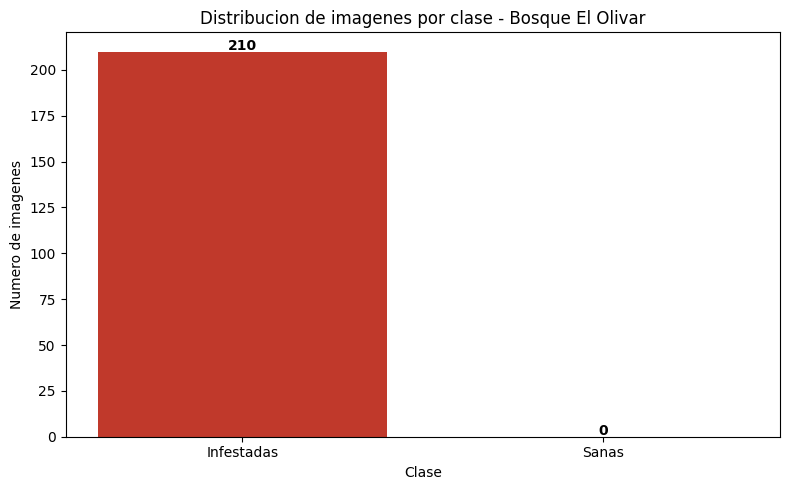

Grafica guardada.


In [9]:
# Grafica de distribucion de clases
clases = ['Infestadas', 'Sanas']
cantidades = [len(infestadas), len(sanas)]

plt.figure(figsize=(8, 5))
plt.bar(clases, cantidades, color=['#c0392b', '#27ae60'])
plt.title('Distribucion de imagenes por clase - Bosque El Olivar')
plt.xlabel('Clase')
plt.ylabel('Numero de imagenes')
for i, v in enumerate(cantidades):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('distribucion_clases.png')
plt.show()
print('Grafica guardada.')

## 4. Distribución de Dimensiones

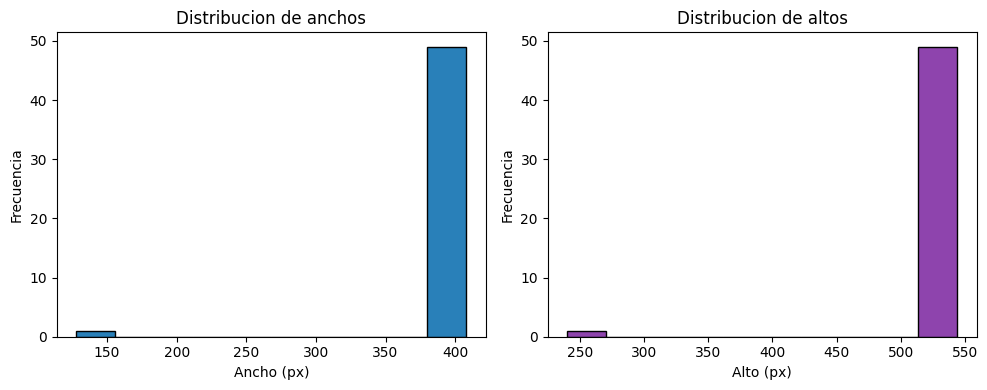

Histograma guardado.


In [10]:
# Histograma de anchos de imagenes
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(anchos, bins=10, color='#2980b9', edgecolor='black')
plt.title('Distribucion de anchos')
plt.xlabel('Ancho (px)')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.hist(altos, bins=10, color='#8e44ad', edgecolor='black')
plt.title('Distribucion de altos')
plt.xlabel('Alto (px)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('distribucion_dimensiones.png')
plt.show()
print('Histograma guardado.')

## 5. Resumen EDA y Riesgos Identificados

In [11]:
# Resumen del EDA
print("===== RESUMEN DEL ANALISIS EXPLORATORIO =====")
print()
print("DATASET:")
print(f"  Total de imagenes        : {len(infestadas) + len(sanas)}")
print(f"  Imagenes infestadas      : {len(infestadas)}")
print(f"  Imagenes sanas           : {len(sanas)}")
print()
print("DIMENSIONES:")
print(f"  Ancho promedio           : {int(np.mean(anchos))} px")
print(f"  Alto promedio            : {int(np.mean(altos))} px")
print(f"  Rango de anchos          : {int(np.min(anchos))} - {int(np.max(anchos))} px")
print(f"  Rango de altos           : {int(np.min(altos))} - {int(np.max(altos))} px")
print()
print("RIESGOS IDENTIFICADOS:")
print("  1. Desbalance de clases: 210 infestadas vs 0 sanas.")
print("     Accion: Capturar imagenes de hojas sanas y aplicar aumento de datos.")
print("  2. Tamano heterogeneo: imagenes entre 128px y 408px de ancho.")
print("     Accion: Estandarizar todas las imagenes a 640x640 px en preprocesamiento.")
print("  3. Variabilidad de iluminacion: fotos tomadas en diferentes horas del dia.")
print("     Accion: Aplicar normalizacion de brillo en preprocesamiento.")
print()
print("CONCLUSIONES ACCIONABLES:")
print("  1. Recolectar minimo 100 imagenes de hojas sanas para balancear el dataset.")
print("  2. Aplicar aumento de datos (rotacion, brillo, contraste) para ampliar")
print("     el dataset hasta aproximadamente 1000 imagenes antes del entrenamiento.")
print("=========================================")

===== RESUMEN DEL ANALISIS EXPLORATORIO =====

DATASET:
  Total de imagenes        : 210
  Imagenes infestadas      : 210
  Imagenes sanas           : 0

DIMENSIONES:
  Ancho promedio           : 402 px
  Alto promedio            : 537 px
  Rango de anchos          : 128 - 408 px
  Rango de altos           : 240 - 544 px

RIESGOS IDENTIFICADOS:
  1. Desbalance de clases: 210 infestadas vs 0 sanas.
     Accion: Capturar imagenes de hojas sanas y aplicar aumento de datos.
  2. Tamano heterogeneo: imagenes entre 128px y 408px de ancho.
     Accion: Estandarizar todas las imagenes a 640x640 px en preprocesamiento.
  3. Variabilidad de iluminacion: fotos tomadas en diferentes horas del dia.
     Accion: Aplicar normalizacion de brillo en preprocesamiento.

CONCLUSIONES ACCIONABLES:
  1. Recolectar minimo 100 imagenes de hojas sanas para balancear el dataset.
  2. Aplicar aumento de datos (rotacion, brillo, contraste) para ampliar
     el dataset hasta aproximadamente 1000 imagenes antes del

## 6. Visualización de Muestras

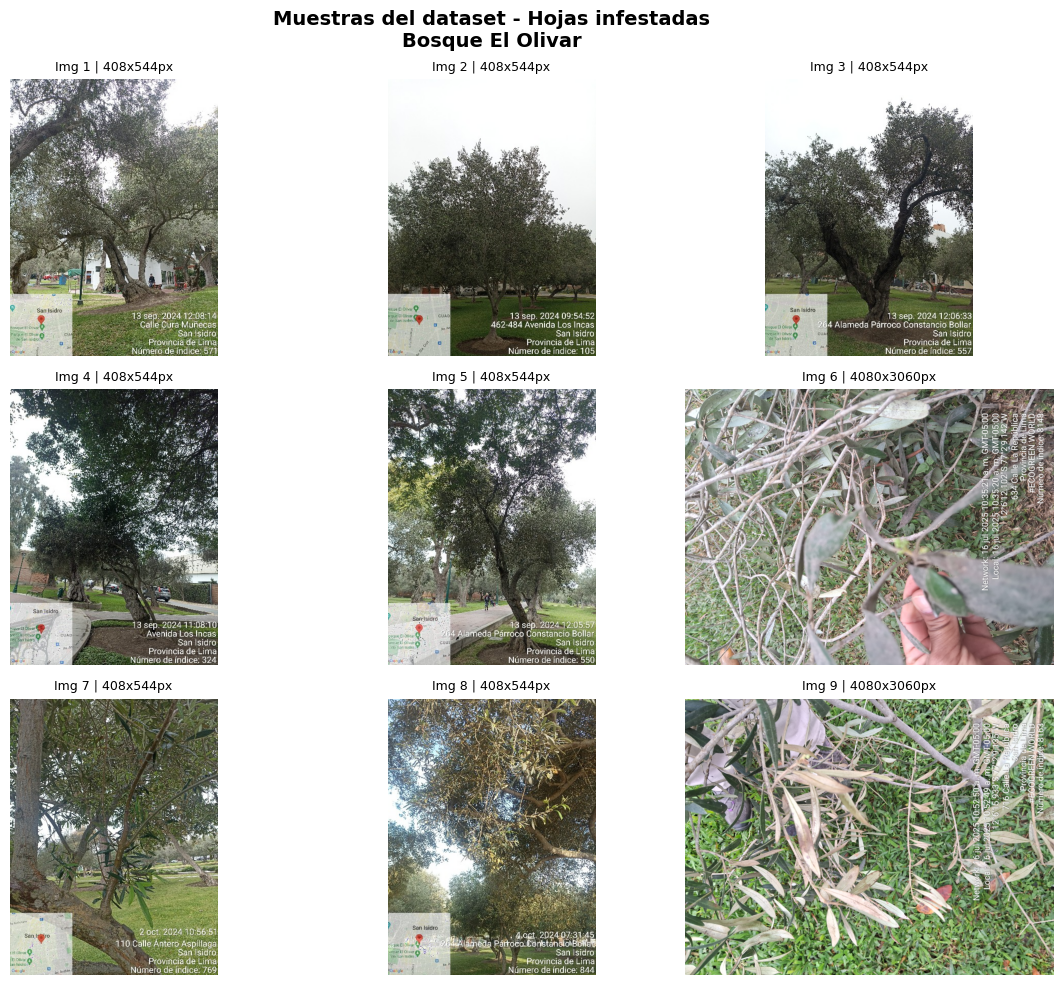

Visualizacion guardada.


In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Mostrar 9 imagenes de muestra
muestra = random.sample(infestadas, min(9, len(infestadas)))

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Muestras del dataset - Hojas infestadas\nBosque El Olivar',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    img = Image.open(muestra[i])
    ax.imshow(img)
    ax.set_title(f'Img {i+1} | {img.size[0]}x{img.size[1]}px', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('muestras_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualizacion guardada.')

## 7. Análisis de Canales RGB

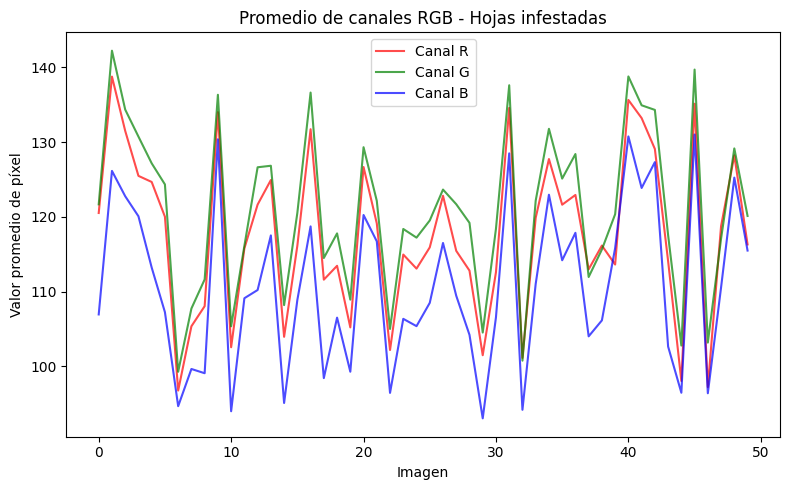

Análisis RGB guardado.


In [13]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

r_vals, g_vals, b_vals = [], [], []

for img_path in infestadas[:50]:
    try:
        img = np.array(Image.open(img_path).convert('RGB'))
        r_vals.append(img[:,:,0].mean())
        g_vals.append(img[:,:,1].mean())
        b_vals.append(img[:,:,2].mean())
    except:
        pass

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r_vals, color='red', alpha=0.7, label='Canal R')
ax.plot(g_vals, color='green', alpha=0.7, label='Canal G')
ax.plot(b_vals, color='blue', alpha=0.7, label='Canal B')
ax.set_title('Promedio de canales RGB - Hojas infestadas')
ax.set_xlabel('Imagen')
ax.set_ylabel('Valor promedio de píxel')
ax.legend()
plt.tight_layout()
plt.savefig('analisis_rgb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Análisis RGB guardado.')

## 8. Baseline Mínimo

In [14]:
import numpy as np
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# Extraer features simples: media RGB de cada imagen
X, y = [], []

for img_path in infestadas:
    try:
        img = np.array(Image.open(img_path).convert('RGB').resize((64, 64)))
        features = [img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()]
        X.append(features)
        y.append(1)  # clase 1 = infestada
    except:
        pass

X = np.array(X)
y = np.array(y)

print(f'Features extraídas: {X.shape}')
print(f'Clases: {np.unique(y, return_counts=True)}')
print()
print('NOTA: Dataset actual tiene solo clase infestada (210 imgs, 0 sanas).')
print('Baseline ejecutado como prueba de pipeline.')
print('Se completará con clase sana una vez capturadas las imágenes.')

# Dummy classifier como baseline
clf = DummyClassifier(strategy='most_frequent')
clf.fit(X, y)
y_pred = clf.predict(X)
print()
print('=== BASELINE (DummyClassifier) ===')
print(classification_report(y, y_pred, target_names=['Infestada']))

Features extraídas: (210, 3)
Clases: (array([1]), array([210]))

NOTA: Dataset actual tiene solo clase infestada (210 imgs, 0 sanas).
Baseline ejecutado como prueba de pipeline.
Se completará con clase sana una vez capturadas las imágenes.

=== BASELINE (DummyClassifier) ===
              precision    recall  f1-score   support

   Infestada       1.00      1.00      1.00       210

    accuracy                           1.00       210
   macro avg       1.00      1.00      1.00       210
weighted avg       1.00      1.00      1.00       210



## 9. Próximos Pasos

In [15]:
print("=== PRÓXIMOS PASOS ===")
print()
print("1. Capturar imágenes de hojas sanas (mínimo 100 imágenes)")
print("   para balancear el dataset (actualmente 210/0)")
print()
print("2. Con dataset balanceado:")
print("   - Reentrenar baseline con clasificación binaria real")
print("   - Experimentar con Variante 1: features HOG + SVM")
print("   - Experimentar con Variante 2: ResNet50 transfer learning")
print()
print("3. Preparar tabla comparativa:")
print("   Baseline vs Variante 1 vs Variante 2")
print("   Métricas: Precision, Recall, F1, mAP@0.5")

=== PRÓXIMOS PASOS ===

1. Capturar imágenes de hojas sanas (mínimo 100 imágenes)
   para balancear el dataset (actualmente 210/0)

2. Con dataset balanceado:
   - Reentrenar baseline con clasificación binaria real
   - Experimentar con Variante 1: features HOG + SVM
   - Experimentar con Variante 2: ResNet50 transfer learning

3. Preparar tabla comparativa:
   Baseline vs Variante 1 vs Variante 2
   Métricas: Precision, Recall, F1, mAP@0.5
